# <font color='gren'> Exercício 5


In [128]:
import numpy as np
import matplotlib.pylab as plt
import scipy
from scipy.sparse import linalg
from scipy.sparse import csc_matrix


## 1 - Funções auxiliares com modificações para o círculo central


* Pré-setagem

In [129]:
N=51
tol=10**(-5)

* Função para plotar os curvas de nível constante de temperatura

In [130]:
# Função para plotar os curvas de nível constante de temperatura
def PlotaTemperature(n,m,T):
    x = np.arange(0, n, 1)
    y = np.arange(0, m, 1)
    X,Y=np.meshgrid(x,y)
    Z = np.copy(T)
    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_aspect('equal')
    ax.set(xlabel='x', ylabel='y', title='Contours of temperature')
    im = ax.contourf(X, Y, Z.T, 20, cmap='jet')
    im2 = ax.contour(X, Y, Z.T, 20, linewidths=0.25, colors='k')
    fig.colorbar(im, ax=ax)
    plt.show()

* Função que adiciona temperatura a um círculo central a placa com um dado raio (que vai de 0.0 a 1.0 da largura da placa) -> sendo necessário in

In [131]:
def temp_circ(N,T,TC,R): #Para os métodos iterativos não gerais
    if(0<=R and R<=1):
        for i in range(0,N):
            for j in range(0,N):
                if( ( i-(N-1)/2 )**2  +  ( j-(N-1)/2 )**2 <= (R*(N-1))**2 ): #Faz a verificação se está dentro
                    T[i][j]=TC

# Função para converter indice (i,j) a indice global Ic
def ij2n (i, j, N):
    return (i + j*N)

def geral_temp_circ(N,Atilde,b,TC,R): #Para os métodos iterativos gerais sem preservação de simetria
    if(0<=R and R<=1):
        for i in range(0,N):
            for j in range(0,N):
                if( ( i-(N-1)/2 )**2  +  ( j-(N-1)/2 )**2 <= (R*(N-1))**2 ): #Faz a verificação se está dentro
                    Ic=ij2n(i,j,N)
                    Atilde[Ic , :]=0
                    Atilde[Ic][Ic]=1
                    b[Ic]=TC
                

def simgeral_temp_circ(N,Atilde,A,b,TC,R): #Para os métodos iterativos gerais com preservação de simetria
    if(0<=R and R<=1):
        for i in range(0,N):
            for j in range(0,N):
                if( ( i-(N-1)/2 )**2  +  ( j-(N-1)/2 )**2 <= (R*(N-1))**2 ): #Faz a verificação se está dentro
                    Ic=ij2n(i,j,N)
                    for k in range(0,N**2):
                        b[k]=b[k]-A[k,Ic]
                    b[Ic]=TC
                    Atilde[Ic][:]=0
                    Atilde[:][Ic]=0
                    Atilde[Ic][Ic]=1
       
        
                    
            

* Métodos de montagem explícita da matriz A

In [132]:

# Função para montar a matriz do sistema
def MatAssembly(N,R):
    nunk = N**2
    A = np.zeros(shape=(nunk,nunk))
    for i in range(1,N-1):
        for j in range(1,N-1):
            if( ( i-(N-1)/2 )**2  +  ( j-(N-1)/2 )**2 >(R*(N-1))**2 ):
                Ic = ij2n(i,   j,   N)
                Ie = ij2n(i+1, j,   N)
                Iw = ij2n(i-1, j,   N)
                In = ij2n(i,   j+1, N)
                Is = ij2n(i,   j-1, N)
                k=np.array([Ic,Ie,Iw,In,Is])
                A[Ic,k] =[4.0, -1.0, -1.0, -1.0, -1.0]
    return A

* Função que coloca temperaturas de borda e monta o sistema

In [133]:
# Função para modificar a matriz e incorporar as condições de borda
def BuildSystem(N, TL, TR, TB, TT, TC, R):
    nunk = N**2
    A = MatAssembly(N,R)
    Atilde = A.copy()
    b = np.zeros(shape=(nunk,1))
    k = np.array(range(0,N))
    Iden = np.identity(nunk)

    geral_temp_circ(N,Atilde,b,TC,R)

    Ic = ij2n(0,k,N)
    Atilde[Ic,:], b[Ic] = Iden[Ic,:], TL # Tleft

    Ic = ij2n(N-1,k,N)
    Atilde[Ic,:], b[Ic] = Iden[Ic,:], TR # Tright

    Ic = ij2n(k,0,N)
    Atilde[Ic,:], b[Ic] = Iden[Ic,:], TB # Tbottom

    Ic = ij2n(k,N-1,N)
    Atilde[Ic,:], b[Ic] = Iden[Ic,:], TT # Ttop
    
    return Atilde, b


* Condições de borda mantendo a simetria

*Observação: para cada Ic[r] o elemento aij correspondete a uma terperatura de borda na matriz b passará 
para o outro lado subtraindo aij x Tj*

In [134]:
# Função para modificar a matriz e incorporar as condições de borda
def BuildSystemSim(N, TL, TR, TB, TT, TC, R):
    nunk = N**2
    A = MatAssembly(N,R)
    Atilde = A.copy()
    b = np.zeros(shape=(nunk))
    k = np.array(range(0,N))
    Iden = np.identity(nunk)

    simgeral_temp_circ(N,Atilde,A,b,TC,R)

    Ic = ij2n(0,k,N) # Tleft
    for r in k:
        b[:] = b[:] - A[:,Ic[r]]*TL 
    Atilde[Ic,:], b[Ic] = Iden[Ic,:], TL
    Atilde[:,Ic] = Iden[:,Ic]

    Ic = ij2n(N-1,k,N) # Tright
    for r in k:
        b[:] = b[:] - A[:,Ic[r]]*TR
    #somente os termos b[Ic[k]] com k variando de 0 a N-1, correspondentes a uma borda,
    #tem a temperatura dessa respectiva borda
    Atilde[Ic,:], b[Ic] = Iden[Ic,:], TR
    Atilde[:,Ic] = Iden[:,Ic]
    
    Ic = ij2n(k,0,N) # Tbottom
    for r in k:
        b[:] = b[:] - A[:,Ic[r]]*TB 
    Atilde[Ic,:], b[Ic] = Iden[Ic,:], TB
    Atilde[:,Ic] = Iden[:,Ic]

    Ic = ij2n(k,N-1,N) # Ttop
    for r in k:
        b[:] = b[:] - A[:,Ic[r]]*TT
    Atilde[Ic,:], b[Ic] = Iden[Ic,:], TT
    Atilde[:,Ic] = Iden[:,Ic]
    
    return Atilde, b

# 2 - Resolvendo com métodos iterativos avançados

In [135]:

class gmres_counter(object):
    def __init__(self, disp=True):
        self._disp = disp
        self.niter = 0
    def __call__(self, rk=None):
        self.niter += 1
        if self._disp:
            print('iter %3i\trk = %s' % (self.niter, str(rk)))
            
import inspect
class cg_counter(object):
    def __init__(self, disp=True):
        self._disp = disp
        self.niter = 0
    def __call__(self, rk=None):
        self.niter += 1
        frame = inspect.currentframe().f_back
        if self._disp:
            print('iter %3i\trk = %f' % (self.niter, frame.f_locals['resid']))


### Plots das curvas de temperatura

* Método direto

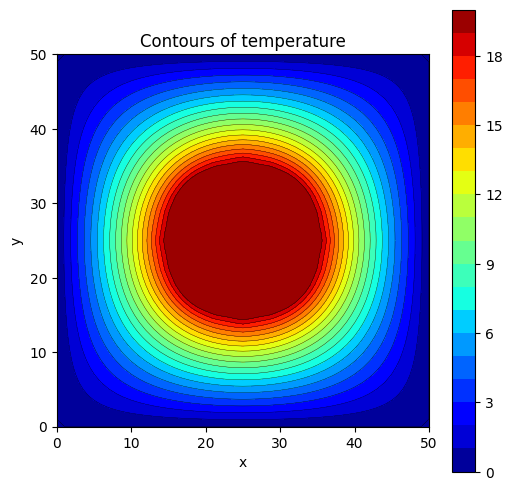

In [136]:
Atilde, b = BuildSystemSim(N, TL=0.0, TR=0.0, TB=0.0, TT=0.0, TC=20.0, R=0.2)
Atildesp = csc_matrix(Atilde)
xsol_dir = scipy.sparse.linalg.spsolve(Atildesp,b)
Tplot = xsol_dir.copy().reshape(N,N).T
PlotaTemperature(N,N,Tplot)

* Método dos gradientes conjugagdos

In [137]:
Atilde, b = BuildSystemSim(N, TL=0.0, TR=0.0, TB=0.0, TT=00.0, TC=20.0, R=0.2)
Atildesp = csc_matrix(Atilde)
xsol_cg, info = scipy.sparse.linalg.cg(Atildesp, b, tol, callback= cg_counter())
Tplot = xsol_cg.copy().reshape(N,N).T
PlotaTemperature(N,N,Tplot)

ValueError: shapes of A (2601, 2601) and x0 () are incompatible

* Método dos resíduos mínimos generalizados

iter   1	rk = 0.5596399722127541
iter   2	rk = 0.30604536776579344
iter   3	rk = 0.19882728720302206
iter   4	rk = 0.1414666954004984
iter   5	rk = 0.10686596511061582
iter   6	rk = 0.0844319068422135
iter   7	rk = 0.06898025772794218
iter   8	rk = 0.05770278106895825
iter   9	rk = 0.049231409938288055
iter  10	rk = 0.04266348130599463
iter  11	rk = 0.03745683004287585
iter  12	rk = 0.033234920678911366
iter  13	rk = 0.02976343574500083
iter  14	rk = 0.026862512381901408
iter  15	rk = 0.024405683154300507
iter  16	rk = 0.022261641160388108
iter  17	rk = 0.0202253386989686
iter  18	rk = 0.01795539032904604
iter  19	rk = 0.015320397824806873
iter  20	rk = 0.01299178965691375
iter  21	rk = 0.011953475006417264
iter  22	rk = 0.010877741237774007
iter  23	rk = 0.009899405789822983
iter  24	rk = 0.00906485227175987
iter  25	rk = 0.008250893124670101
iter  26	rk = 0.00744444768850813
iter  27	rk = 0.006673083616421183
iter  28	rk = 0.005860439603113921
iter  29	rk = 0.005119688461367012
iter 

/tmp/ipykernel_4772/2210387298.py:3: DeprecationWarning: scipy.sparse.linalg.gmres called without specifying `callback_type`. The default value will be changed in a future release. For compatibility, specify a value for `callback_type` explicitly, e.g., ``gmres(..., callback_type='pr_norm')``, or to retain the old behavior ``gmres(..., callback_type='legacy')``
  xsol_gmres, info = scipy.sparse.linalg.gmres(Atildesp, b, tol=1e-5, callback=gmres_counter())
/tmp/ipykernel_4772/2210387298.py:3: DeprecationWarning: 'scipy.sparse.linalg.gmres' keyword argument `tol` is deprecated in favor of `rtol` and will be removed in SciPy v1.14.0. Until then, if set, it will override `rtol`.
  xsol_gmres, info = scipy.sparse.linalg.gmres(Atildesp, b, tol=1e-5, callback=gmres_counter())


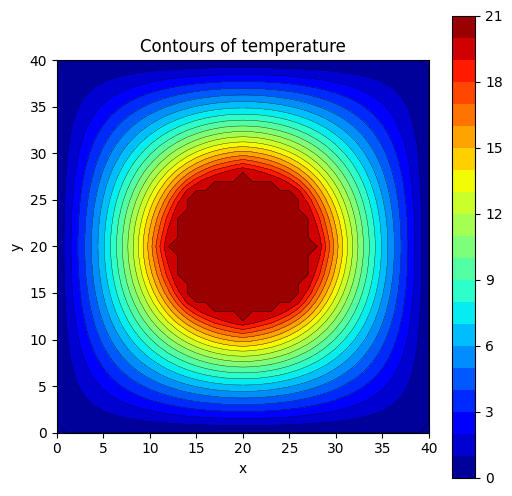

In [ ]:
Atilde, b = BuildSystemSim(N, TL=0.0, TR=0.0, TB=0.0, TT=0.0, TC=20.0, R=0.2)
Atildesp = csc_matrix(Atilde)
xsol_gmres, info = scipy.sparse.linalg.gmres(Atildesp, b, tol, callback=gmres_counter())
Tplot = xsol_gmres.copy().reshape(N,N).T
PlotaTemperature(N,N,Tplot)